# SuperReso

### Super Resolution with stupid ML

In [1]:
# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from scipy import ndimage
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image, ImageFilter
from tqdm import tqdm

In [2]:
class CustomDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        # return len(self.image_paths)
        return 32 # Hack to get batch size 32 from single image

    def __getitem__(self, idx):
        MIN_PATCH = 16. # For crop and resize
        MAX_PATCH = 64. # For crop and resize
        BLUR_RADIUS = 16 # For Gaussian Blur
        
        # img_path = self.image_paths[idx]
        img_path = self.image_paths[0] # Hack to get batch size 32 from single image
        image = Image.open(img_path).convert('RGB')
        width, height = image.size
        blurred_image = Image.open(img_path).convert('RGB').filter(ImageFilter.GaussianBlur(radius=BLUR_RADIUS))

        # Apply transformations
        d = transforms.RandomRotation.get_params([-180, 180])
        image = TF.rotate(image, d)
        blurred_image = TF.rotate(blurred_image, d)
        
        t, b, c, s, h = transforms.ColorJitter.get_params(
            brightness=[0.8, 1.2], 
            contrast=[0.8, 1.2], 
            saturation=[0.8, 1.2], 
            hue=[0, 0.1]
        )
        image = TF.adjust_brightness(image, b)
        blurred_image = TF.adjust_brightness(blurred_image, b)
        image = TF.adjust_contrast(image, c)
        blurred_image = TF.adjust_contrast(blurred_image, c)
        image = TF.adjust_saturation(image, s)
        blurred_image = TF.adjust_saturation(blurred_image, s)
        image = TF.adjust_hue(image, h)
        blurred_image = TF.adjust_hue(blurred_image, h)
    
        if random.random() > 0.5:
            image = TF.hflip(image)
            blurred_image = TF.hflip(blurred_image)
        if random.random() > 0.5:
            image = TF.vflip(image)
            blurred_image = TF.vflip(blurred_image)
        i, j, h, w = transforms.RandomResizedCrop.get_params(
            image, 
            scale=(max(MIN_PATCH/width, MIN_PATCH/height), max(MAX_PATCH/width, MAX_PATCH/height)), # TODO: Make these const vars
            ratio=(0.75, 1.25)
        )

        image = TF.resize(TF.crop(image, i, j, h, w), (16, 16))
        blurred_image = TF.resize(TF.crop(blurred_image, i, j, h, w), (16, 16))
    
        
        image = transforms.ToTensor()(image)
        blurred_image = transforms.ToTensor()(blurred_image)
        
        # TODO: Perhaps I should be learning the difference?
        diff_image = image - blurred_image
        return diff_image, blurred_image

torch.Size([32, 3, 16, 16])


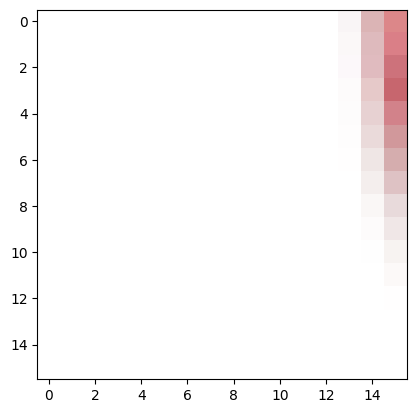

torch.Size([32, 3, 16, 16])


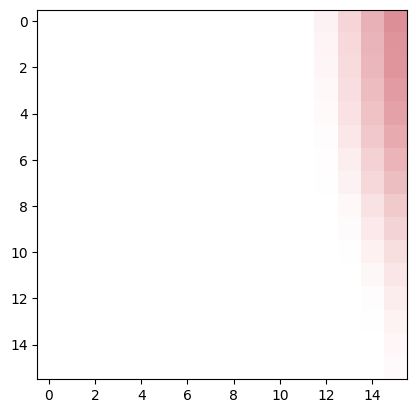

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


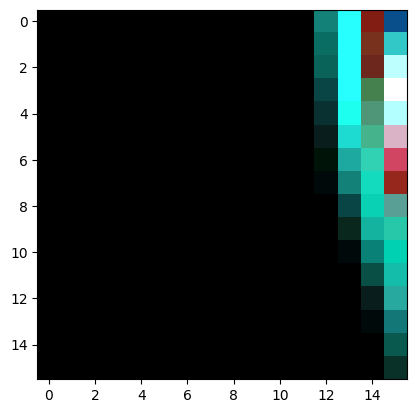

In [3]:
# Example usage
image_paths = ["raspberry.jpg"]  # List of paths to your images
custom_dataset = CustomDataset(image_paths)
data_loader = DataLoader(custom_dataset, batch_size=32, shuffle=True)

# Iterate over the data loader
for diff_image, blurred_sample in data_loader:
    # batch is a tensor of shape [batch_size, channels, height, width]
    original_sample = diff_image + blurred_sample
    print(original_sample.shape)
    plt.imshow(original_sample[0].permute(1, 2, 0))
    plt.show()
    
    print(blurred_sample.shape)
    plt.imshow(blurred_sample[0].permute(1, 2, 0))
    plt.show()
    
    plt.imshow(np.abs(diff_image[0].permute(1, 2, 0) * 10))
    plt.show()

In [7]:
# Define Model Architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x

  2%|██▋                                                                                                                                     | 1/50 [00:01<01:31,  1.87s/it]

torch.Size([32, 3, 16, 16]) torch.Size([32, 3, 16, 16])
Epoch [1/50], Loss: 0.014605528675019741


  4%|█████▍                                                                                                                                  | 2/50 [00:03<01:24,  1.76s/it]

torch.Size([32, 3, 16, 16]) torch.Size([32, 3, 16, 16])
Epoch [2/50], Loss: 0.008970911614596844


  6%|████████▏                                                                                                                               | 3/50 [00:05<01:21,  1.74s/it]

...

torch.Size([32, 3, 16, 16]) torch.Size([32, 3, 16, 16])
Epoch [48/50], Loss: 0.0028461243491619825


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎  | 49/50 [01:24<00:01,  1.73s/it]

torch.Size([32, 3, 16, 16]) torch.Size([32, 3, 16, 16])
Epoch [49/50], Loss: 0.0037830097135156393


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:26<00:00,  1.73s/it]

torch.Size([32, 3, 16, 16]) torch.Size([32, 3, 16, 16])
Epoch [50/50], Loss: 0.002398124663159251


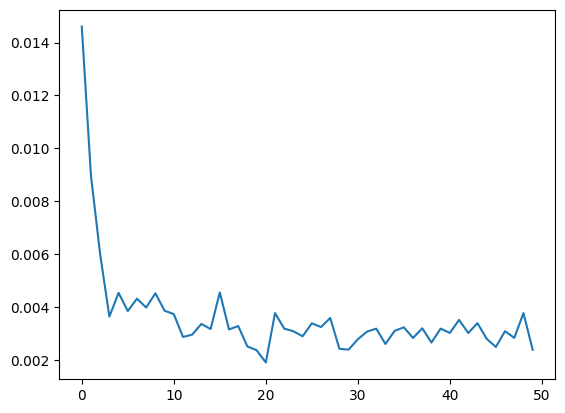

In [20]:
# Initialize the model
model = SimpleCNN()

# Define the loss function
criterion = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
NUM_EPOCHS = 50
losses = []
for epoch in tqdm(range(NUM_EPOCHS)):
    # Both images are torch Tensors of shape (batch_size, channels, height, width)
    diff_sample, blurred_sample = next(iter( data_loader))
    optimizer.zero_grad()  # Clear gradients
    output = model(blurred_sample)  # Forward pass
    print(output.shape, diff_sample.shape)
    loss = criterion(output, diff_sample)  # Calculate loss
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights
    losses.append(loss.item())
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {loss.item()}")
    
plt.plot(losses)
plt.show()

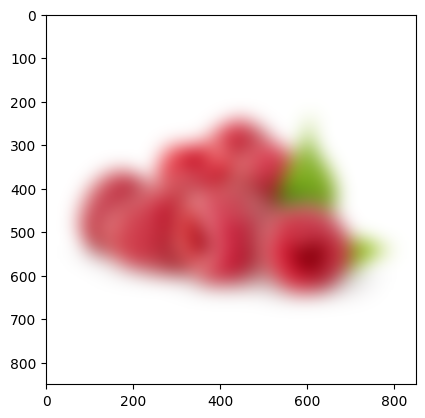

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


0.0157247893512249 1.0326930657029152


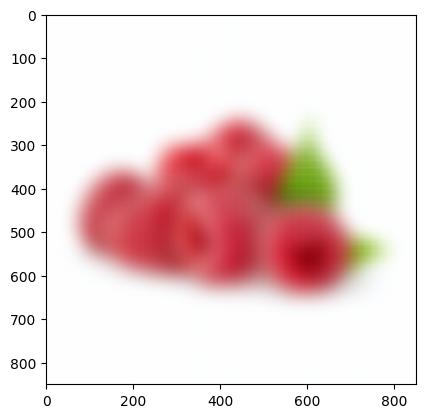

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


-0.054072652012109756 0.03269306570291519


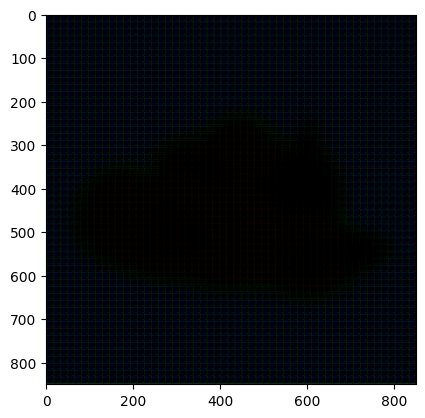

In [37]:
# Do a sample test:
PATCH_SIZE = 16
sample_raspberry = Image.open('raspberry.jpg').convert('RGB').filter(ImageFilter.GaussianBlur(radius=20))
width, height = sample_raspberry.size
output = np.zeros((width, height, 3))
sample_raspberry = transforms.ToTensor()(sample_raspberry)
# print(sample_patch.shape)
with torch.no_grad():
    for i in range(0, width, PATCH_SIZE):
        for j in range(0, height, PATCH_SIZE):
            
            patch = sample_raspberry[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            output[i:i+PATCH_SIZE, j:j+PATCH_SIZE, :] = model(patch).permute(1, 2, 0)

plt.imshow(sample_raspberry.permute(1, 2, 0).numpy())
plt.show()
print(np.min(output+sample_raspberry.permute(1, 2, 0).numpy()), np.max(output+sample_raspberry.permute(1, 2, 0).numpy()))
plt.imshow(output+sample_raspberry.permute(1, 2, 0).numpy())
plt.show()

plt.imshow(output * 10)
print(np.min(output), np.max(output))
plt.show()